<a href="https://colab.research.google.com/github/ElizabethFrankWebb/USRI-2026/blob/main/replicating_limits_to_adaptation_along_environmental_gradients_simulations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

n_demes = 100
K = 50
generations = 200
sigma = 1.0
b = 0.1
Vs = 1.0
Vm = 0.05

optimums = np.linspace (0, b*n_demes, n_demes)

population = []
for x in range (40, 60):
  for _ in range(k):
    population.append([x, optimums[x]])
population = np.array(population)


In [ ]:
import gc

for gen in range(generations):
  locations = population[:, 0].astype(int)
  traits = population[:, 1]
  fitness = np.exp(-(traits - optimums[locations])**2 / (2 * Vs))
  survivors_mask = np.random.rand(len(population)) < fitness
  population = population[survivors_mask]

  if len(population) > 0:
    offspring_traits = population[:, 1] + np.random.normal(0, np.sqrt(Vm), len(population))
    offspring = np.column_stack((population[:,0], offspring_traits))
    population = np.vstack((population, offspring))

  population[:, 0] += np.random.normal(0, sigma, len(population)).round()

  population[:, 0] = np.clip(population[:, 0], 0, n_demes - 1)

  new_pop_list=[]
  for d in range(n_demes):
      deme_pop = population[population[:, 0] == d]
      if len(deme_pop)> K:
          idx = np.random.choice(len(deme_pop), K, replace=False)
          deme_pop = deme_pop[idx]
      if len(deme_pop)> 0:
             new_pop_list.append(deme_pop)

  if len(new_pop_list) > 0:
      population = np. vstack(new_pop_list)
  else:
      print(f"Extinction at generation {gen}")
      break

print("Simulation Complete!")


Simulation Complete!


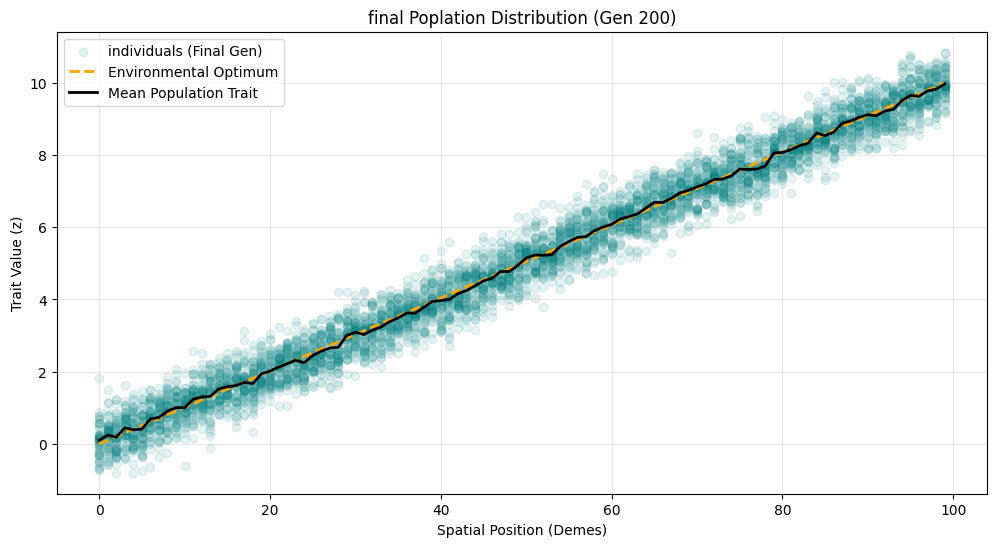

In [ ]:
plt.figure(figsize=(12, 6))

plt.scatter(population[:, 0], population[:, 1], alpha=0.1, color='teal', label="individuals (Final Gen)")

plt.plot(optimums, color='orange', linestyle= "--", linewidth=2, label="Environmental Optimum")

final_averages = []
active_demes = []
for d in range(n_demes):
    deme_traits = population[population[:, 0]== d][:, 1]
    if len(deme_traits)> 0:
        final_averages.append(np.mean(deme_traits))
        active_demes.append(d)

plt.plot(active_demes, final_averages, color='black', linewidth=2, label="Mean Population Trait")

plt. title(f"final Poplation Distribution (Gen {generations})")
plt.xlabel("Spatial Position (Demes)")
plt.ylabel("Trait Value (z)")
plt.legend ()
plt.grid(True, alpha=0.3)
plt.show()
